# Chapter 5: Data Visualization & Storytelling
## Section 5.6: End-to-End Case Study - Twitter Stock Market Analysis

### 1. Introduction & Dataset Overview
**Dataset Description:** This dataset contains historical stock market data for Twitter, Inc. (ticker: TWTR) from the date of its IPO on November 7, 2013, onwards. The analysis focuses on understanding price trends, volatility, and trading activity.

**Source URL:** [Twitter Stock Market Analysis Case Study](https://www.kaggle.com/datasets/bhanupratapbiswas/twitter-stock-market-analysis-case-study/data/)

**Columns:**
- `Date`: The specific trading day (formatted as YYYY-MM-DD).
- `Open`: The price at which the stock first traded when the market opened.
- `High`: The maximum price reached during the trading session.
- `Low`: The minimum price reached during the trading session.
- `Close`: The final price at which the stock was traded for the day.
- `Adj Close`: The closing price adjusted for dividends, stock splits, and new stock offerings.
- `Volume`: The total number of shares traded on that day.

**Research Questions:**
- What has been the long-term trend of Twitter's closing price?
- How does the trading volume correlate with price movement?
- Is there seasonality or difference in price volatility based on the year?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Setting aesthetic styles
plt.style.use('fivethirtyeight')
sns.set_palette("coolwarm")
sns.set_context("notebook", font_scale=1.2)

# Create directory for charts if it doesn't exist
if not os.path.exists('charts'):
    os.makedirs('charts')

### 2. Data Loading & Cleaning
This section involves loading the CSV file, checking for missing values, and preparing the data for visualization by ensuring correct data types and creating helpful extra columns.

In [2]:
# Load the dataset
df = pd.read_csv('twitter_stock.csv')

# Convert Date to datetime object
df['Date'] = pd.to_datetime(df['Date'])

# Handle missing values and zero volume
df = df.dropna()
df = df[df['Volume'] > 0]

# Check overview
print("--- Dataset Head ---")
display(df.head())

print("\n--- Dataset Info ---")
display(df.info())

print("\n--- Missing Values ---")
display(df.isnull().sum())

print("\n--- Summary Statistics ---")
display(df.describe())

--- Dataset Head ---


,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-11-07,45.099998,50.090000,44.000000,44.900002,44.900002,117701670.0
1,2013-11-08,45.930000,46.939999,40.685001,41.650002,41.650002,27925307.0
2,2013-11-11,40.500000,43.000000,39.400002,42.900002,42.900002,16113941.0
3,2013-11-12,43.660000,43.779999,41.830002,41.900002,41.900002,6316755.0
4,2013-11-13,41.029999,42.869999,40.759998,42.599998,42.599998,8688325.0



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 2257 entries, 0 to 2258
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2257 non-null   datetime64[ns]
 1   Open       2257 non-null   float64       
 2   High       2257 non-null   float64       
 3   Low        2257 non-null   float64       
 4   Close      2257 non-null   float64       
 5   Adj Close  2257 non-null   float64       
 6   Volume     2257 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 141.1 KB


None


--- Missing Values ---


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


--- Summary Statistics ---


,Date,Open,High,Low,Close,Adj Close,Volume
count,2257,2257.000000,2257.000000,2257.000000,2257.000000,2257.000000,2.257000e+03
mean,2018-05-05 09:05:30.172795648,36.032700,36.712694,35.351640,36.016172,36.016172,2.177114e+07
min,2013-11-07 00:00:00,13.950000,14.220000,13.725000,14.010000,14.010000,3.661053e+06
25%,2016-02-08 00:00:00,25.559999,26.230000,24.915001,25.410000,25.410000,1.236071e+07
50%,2018-05-07 00:00:00,35.430000,36.110001,34.830002,35.500000,35.500000,1.695544e+07
75%,2020-08-03 00:00:00,44.209999,45.029999,43.330002,44.139999,44.139999,2.428113e+07
max,2022-10-27 00:00:00,78.360001,80.750000,76.050003,77.629997,77.629997,2.692131e+08
std,NaN,14.117756,14.371126,13.827989,14.089141,14.089141,1.909736e+07


#### Data Enhancement
I'll extract 'Year' and 'Month' from the Date column to facilitate categorical comparisons.

In [3]:
# Extract features for categorical analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Daily_Change'] = df['Close'] - df['Open']

print("Updated DF with Year and Month columns:")
display(df.head())

Updated DF with Year and Month columns:


,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day_of_Week,Daily_Change
0,2013-11-07,45.099998,50.090000,44.000000,44.900002,44.900002,117701670.0,2013,November,Thursday,-0.199996
1,2013-11-08,45.930000,46.939999,40.685001,41.650002,41.650002,27925307.0,2013,November,Friday,-4.279998
2,2013-11-11,40.500000,43.000000,39.400002,42.900002,42.900002,16113941.0,2013,November,Monday,2.400002
3,2013-11-12,43.660000,43.779999,41.830002,41.900002,41.900002,6316755.0,2013,November,Tuesday,-1.759998
4,2013-11-13,41.029999,42.869999,40.759998,42.599998,42.599998,8688325.0,2013,November,Wednesday,1.569999


### 3. Matplotlib Visualizations
I will produce individual charts for line, bar, histogram, and scatter plots, plus a subplot grid.

#### 3.1 Line Chart: Twitter Stock Closing Price Over Time
**Insight:** This chart shows the long-term price trend. We can observe periods of peak enthusiasm and subsequent declines.

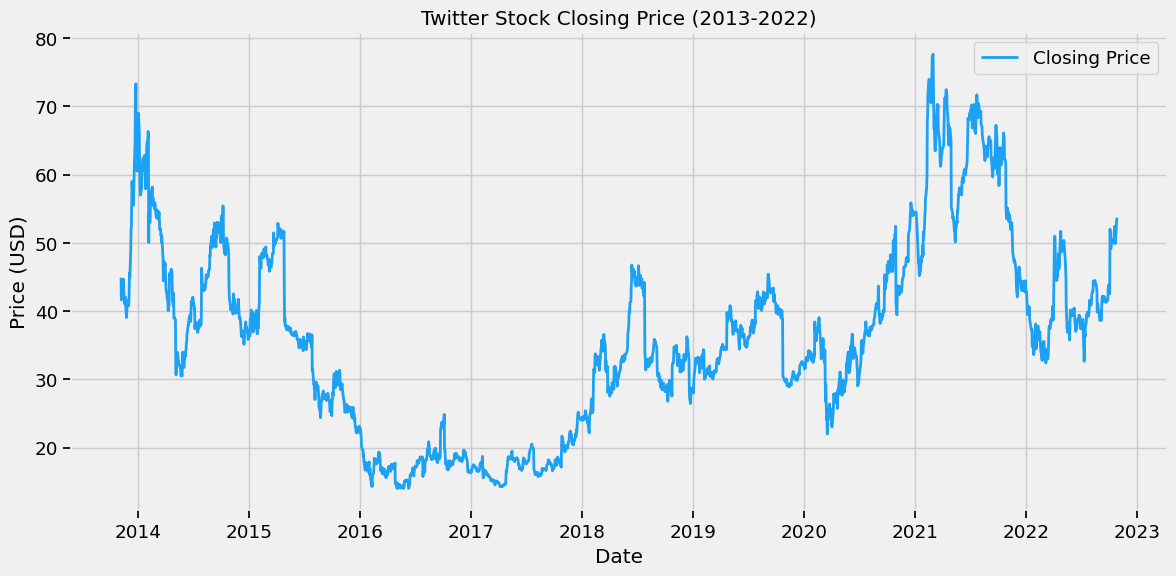

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], color='#1DA1F2', linewidth=2, label='Closing Price')
plt.title('Twitter Stock Closing Price (2013-2022)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/line_price.png', dpi=150)
plt.show()

#### 3.2 Bar Chart: Average Trading Volume per Year
**Insight:** This chart demonstrates whether trading activity has grown or shrunk over the years.

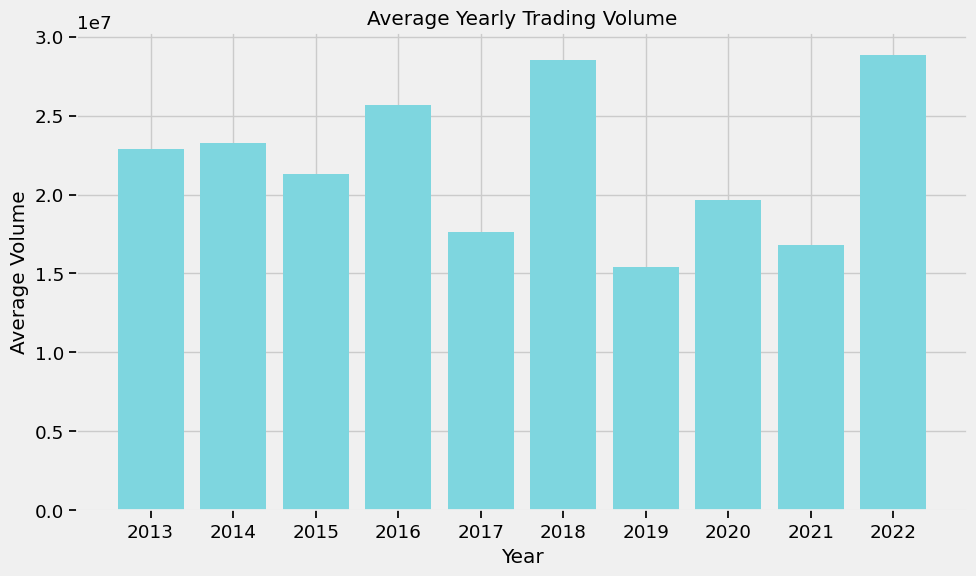

In [5]:
yearly_avg_vol = df.groupby('Year')['Volume'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(yearly_avg_vol['Year'], yearly_avg_vol['Volume'], color='#7ed6df')
plt.title('Average Yearly Trading Volume')
plt.xlabel('Year')
plt.ylabel('Average Volume')
plt.xticks(yearly_avg_vol['Year'])
plt.tight_layout()
plt.savefig('charts/bar_volume.png', dpi=150)
plt.show()

#### 3.3 Histogram: Distribution of Daily Closing Prices
**Insight:** This histogram reveals the most frequent price range for the stock across the entire period.

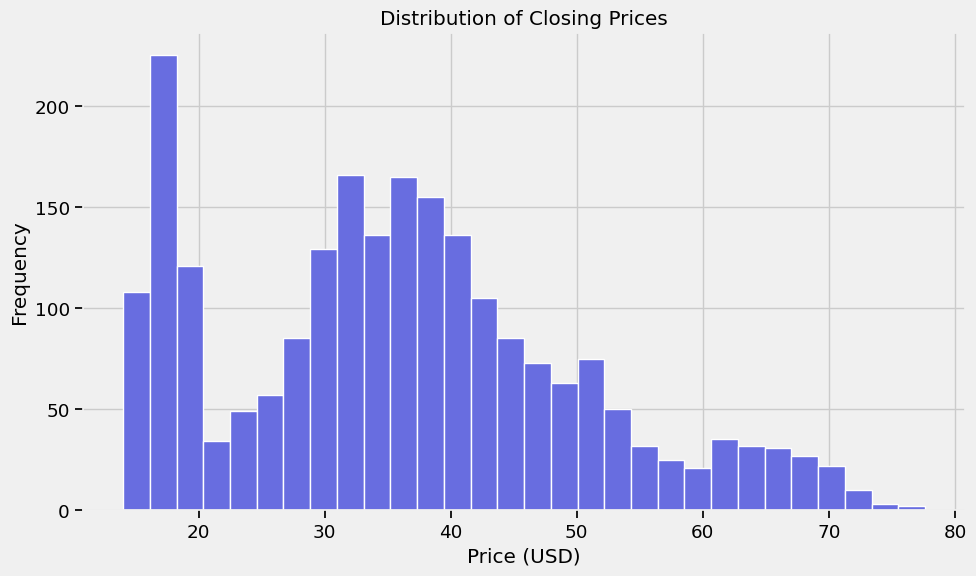

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df['Close'], bins=30, color='#686de0', edgecolor='white')
plt.title('Distribution of Closing Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('charts/hist_price.png', dpi=150)
plt.show()

#### 3.4 Scatter Plot: Relationship between Volume and Daily Change
**Insight:** This plot examines whether high trading volume is associated with larger price swings (volatility).

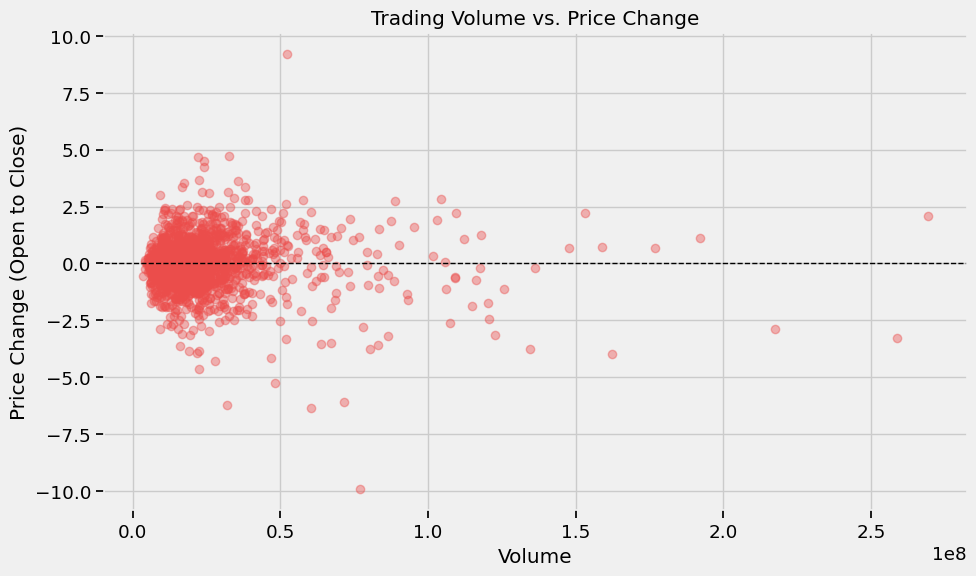

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Volume'], df['Daily_Change'], alpha=0.4, color='#eb4d4b')
plt.title('Trading Volume vs. Price Change')
plt.xlabel('Volume')
plt.ylabel('Price Change (Open to Close)')
plt.axhline(0, color='black', lw=1, ls='--')
plt.tight_layout()
plt.savefig('charts/scatter_vol_change.png', dpi=150)
plt.show()

#### 3.5 Subplot Grid: Highs and Lows Analysis
**Insight:** Comparing Open vs Close and High vs Low patterns side-by-side using subplots.

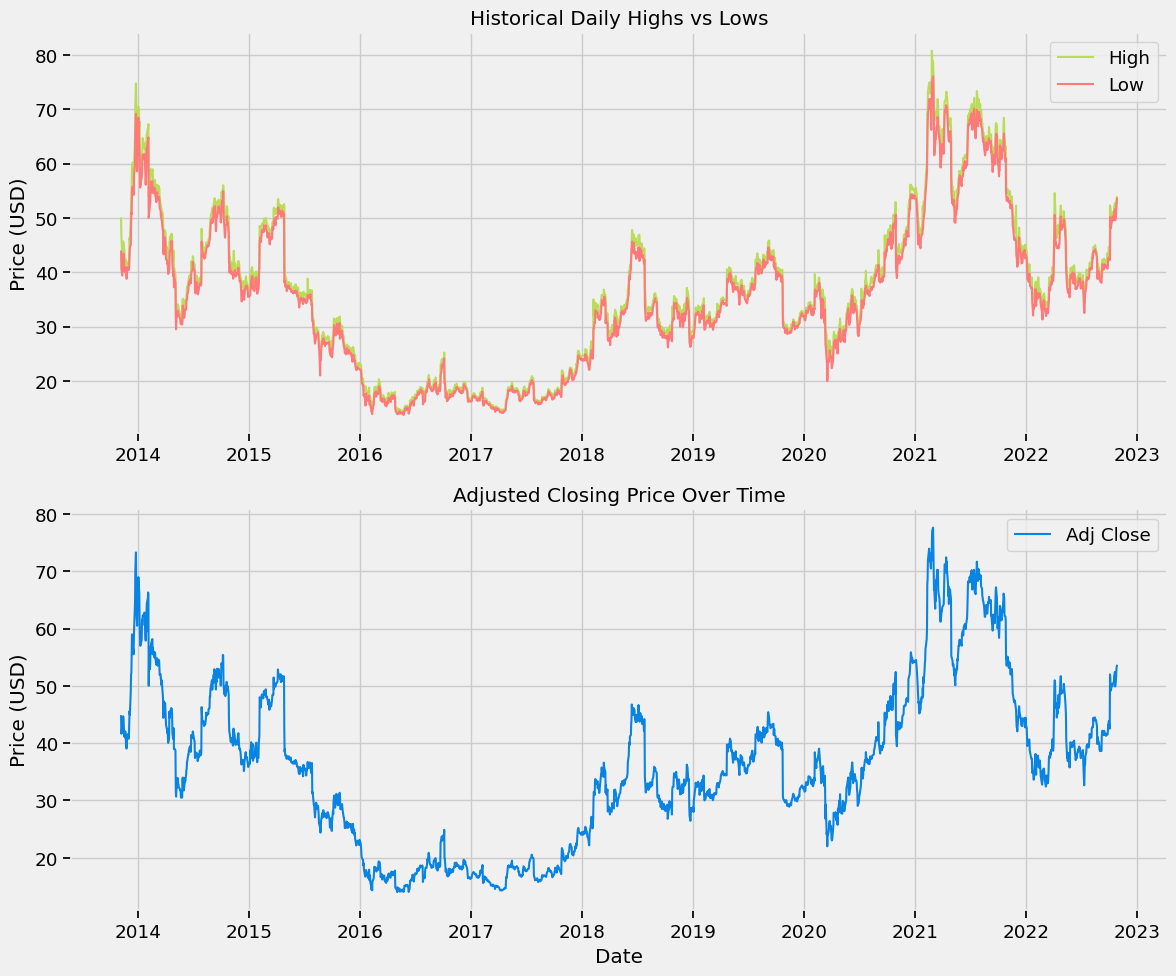

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# High-Low Plot
axes[0].plot(df['Date'], df['High'], color='#badc58', label='High')
axes[0].plot(df['Date'], df['Low'], color='#ff7979', label='Low')
axes[0].set_title('Historical Daily Highs vs Lows')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Adj Close Plot
axes[1].plot(df['Date'], df['Adj Close'], color='#0984e3', label='Adj Close')
axes[1].set_title('Adjusted Closing Price Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/subplots_high_low.png', dpi=150)
plt.show()

### 4. Seaborn Statistical Plots
Seaborn allows for more advanced statistical insights with cleaner aesthetics.

#### 4.1 Box Plot: Closing Price Distribution by Year
**Insight:** This chart shows the median price and volatility (spread) for each year.

/var/folders/nb/_rv6f3v52rq4wx3ktv25ltvr0000gn/T/ipykernel_21540/3641730056.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Close', data=df, palette='coolwarm')


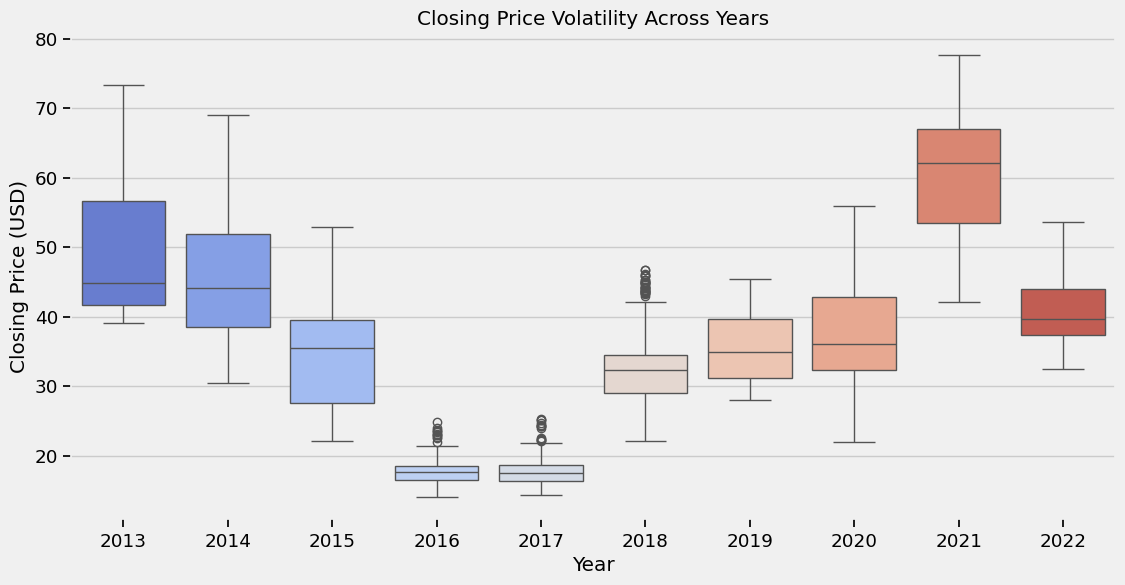

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='Close', data=df, palette='coolwarm')
plt.title('Closing Price Volatility Across Years')
plt.xlabel('Year')
plt.ylabel('Closing Price (USD)')
plt.savefig('charts/seaborn_boxplot.png', dpi=150)
plt.show()

#### 4.2 Correlation Heatmap
**Insight:** Shows how highly correlated different price metrics are.

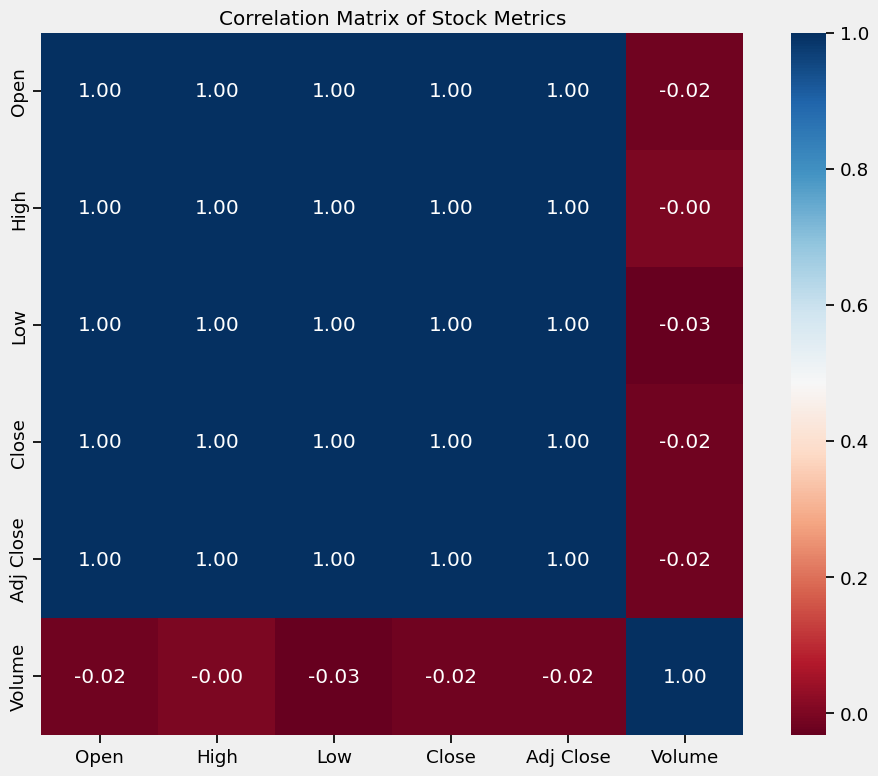

In [10]:
plt.figure(figsize=(10, 8))
corr = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu', fmt='.2f', square=True)
plt.title('Correlation Matrix of Stock Metrics')
plt.tight_layout()
plt.savefig('charts/seaborn_heatmap.png', dpi=150)
plt.show()

#### 4.3 Pair Plot: Relationships Between Key Metrics
**Insight:** Visualizes multiple relationships simultaneously across a subset of numeric data.

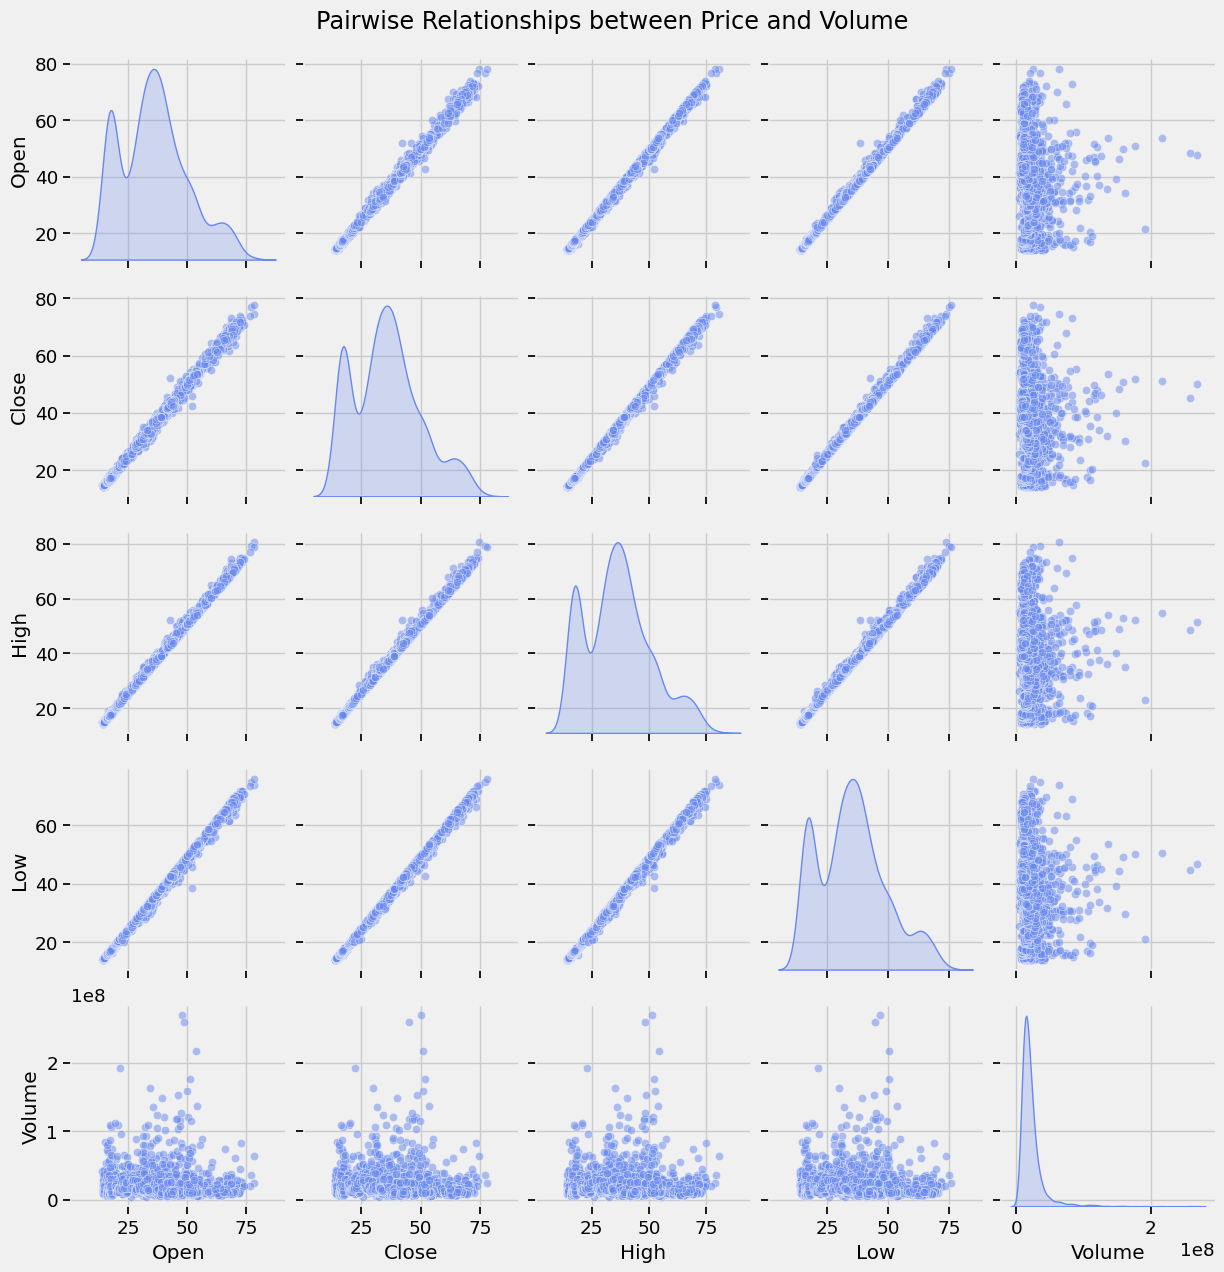

In [11]:
numeric_subset = df[['Open', 'Close', 'High', 'Low', 'Volume']]
sns.pairplot(numeric_subset, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Relationships between Price and Volume', y=1.02)
plt.savefig('charts/seaborn_pairplot.png', dpi=150)
plt.show()

### 5. Plotly Interactive Chart
Interactive charts allow for better exploration of specific data points.

In [12]:
# Normalize bubble size to avoid errors if some values are extreme
df['Bubble_Size'] = (df['Volume'] - df['Volume'].min()) / (df['Volume'].max() - df['Volume'].min()) * 100
df['Bubble_Size'] = df['Bubble_Size'].fillna(10)

fig = px.scatter(df, x="Date", y="Close", 
                 size="Bubble_Size",
                 color="Year", 
                 hover_name="Date", hover_data=["Open", "Volume"], 
                 title="Interactive Price & Volume Bubble Chart Over Time")
fig.update_layout(xaxis_title="Date", yaxis_title="Closing Price (USD)")
fig.show()
fig.write_image('charts/plotly_interactive.png')

/var/folders/nb/_rv6f3v52rq4wx3ktv25ltvr0000gn/T/ipykernel_21540/2273772248.py:12: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image('charts/plotly_interactive.png')


## 5. witter Stock Analysis: Master Subplot Dashboard

/var/folders/nb/_rv6f3v52rq4wx3ktv25ltvr0000gn/T/ipykernel_21540/454203032.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Close', data=df, palette='Set3', ax=axes[2, 0])
/var/folders/nb/_rv6f3v52rq4wx3ktv25ltvr0000gn/T/ipykernel_21540/454203032.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2, 0].set_xticklabels(axes[2, 0].get_xticklabels(), rotation=45)


Master subplot dashboard generated at charts/master_subplot_dashboard.png


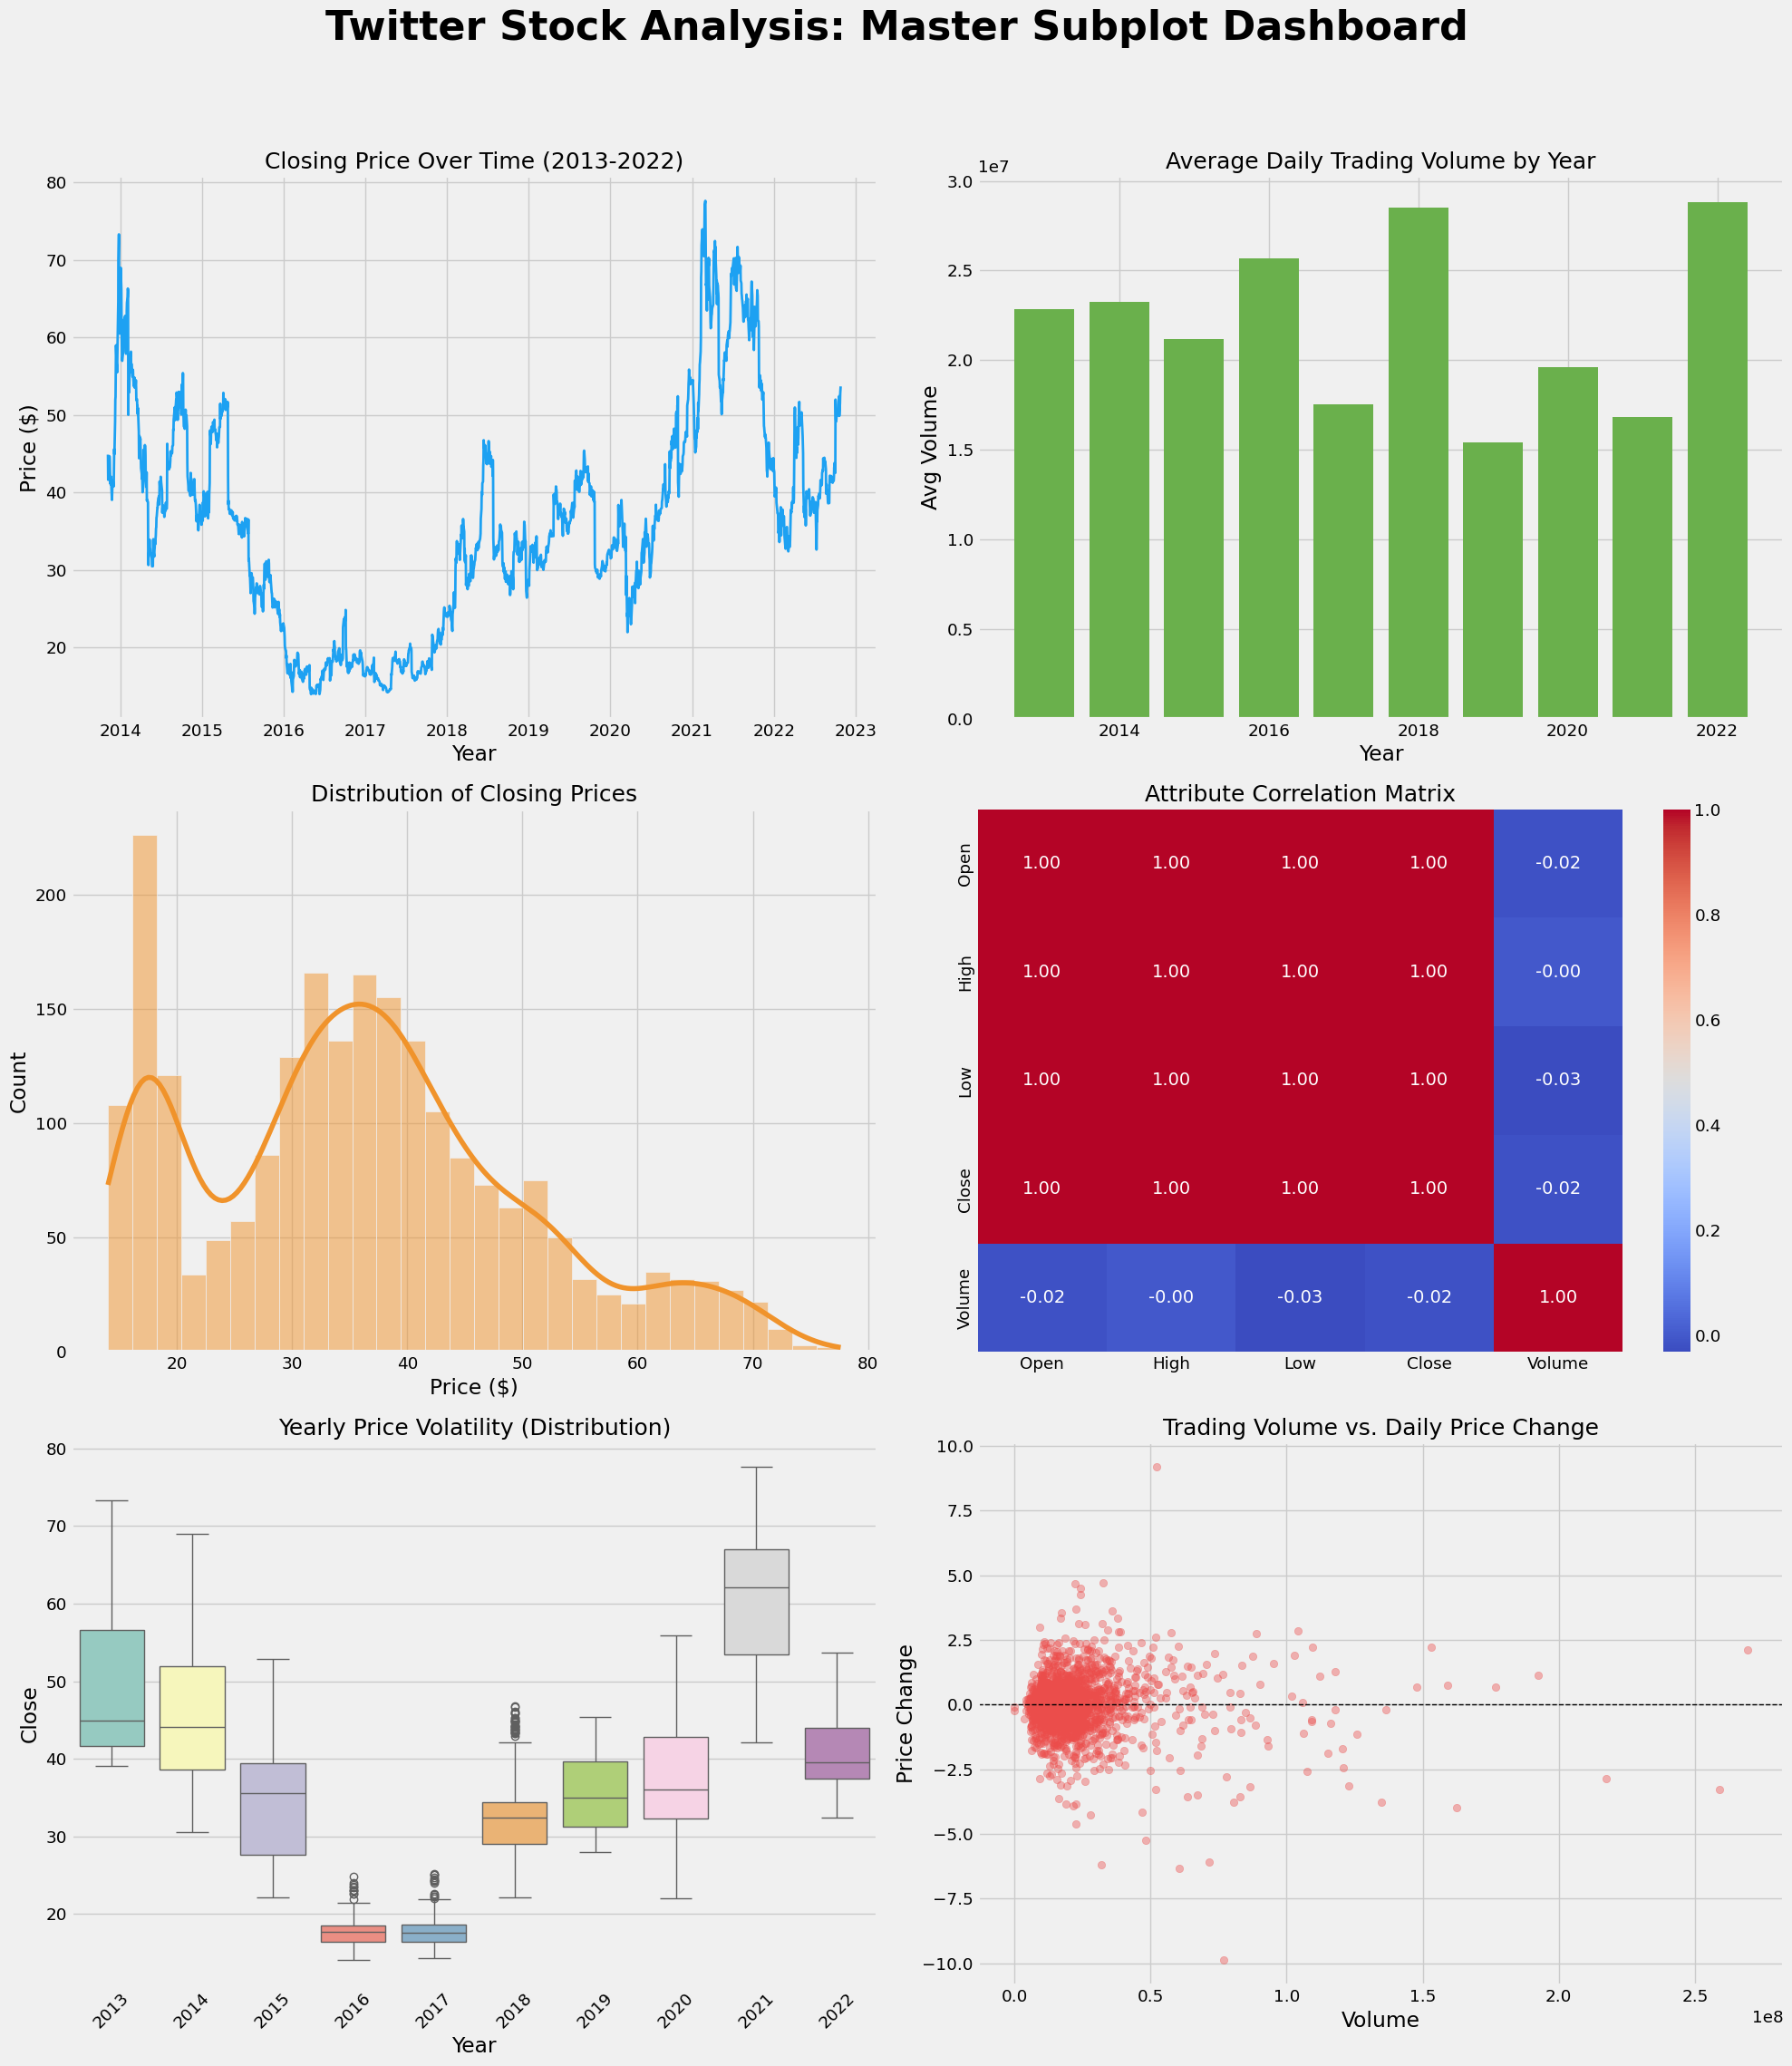

In [13]:

# Set style
plt.style.use('fivethirtyeight')
sns.set_palette("coolwarm")

# Load data
df = pd.read_csv('twitter_stock.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Daily_Change'] = df['Close'] - df['Open']

# Create a master figure with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(20, 24))
fig.suptitle("Twitter Stock Analysis: Master Subplot Dashboard", fontsize=32, fontweight='bold', y=0.98)

# 1. Line Chart: Price Evolution
axes[0, 0].plot(df['Date'], df['Close'], color='#1da1f2', linewidth=2)
axes[0, 0].set_title('Closing Price Over Time (2013-2022)', fontsize=18)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Price ($)')

# 2. Bar Chart: Average Volume by Year
yearly_vol = df.groupby('Year')['Volume'].mean().reset_index()
axes[0, 1].bar(yearly_vol['Year'], yearly_vol['Volume'], color='#6ab04c')
axes[0, 1].set_title('Average Daily Trading Volume by Year', fontsize=18)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Avg Volume')

# 3. Histogram: Price Distribution
sns.histplot(df['Close'], bins=30, kde=True, color='#f0932b', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Closing Prices', fontsize=18)
axes[1, 0].set_xlabel('Price ($)')

# 4. Heatmap: Correlation Matrix
corr = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Attribute Correlation Matrix', fontsize=18)

# 5. Boxplot: Yearly Price Range
sns.boxplot(x='Year', y='Close', data=df, palette='Set3', ax=axes[2, 0])
axes[2, 0].set_title('Yearly Price Volatility (Distribution)', fontsize=18)
axes[2, 0].set_xticklabels(axes[2, 0].get_xticklabels(), rotation=45)

# 6. Scatter: Volume vs. Daily Change
axes[2, 1].scatter(df['Volume'], df['Daily_Change'], alpha=0.4, color='#eb4d4b')
axes[2, 1].axhline(0, color='black', lw=1, ls='--')
axes[2, 1].set_title('Trading Volume vs. Daily Price Change', fontsize=18)
axes[2, 1].set_xlabel('Volume')
axes[2, 1].set_ylabel('Price Change')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('charts/master_subplot_dashboard.png', dpi=150)
print("Master subplot dashboard generated at charts/master_subplot_dashboard.png")


### 6. Insight Summary

1. **Observation:** From the *Line Chart (3.1)*, Twitter stock price showed significant growth starting late 2020 through early 2021 before experiencing a sharp correction.
   - **Explanation:** This era correlates with the pandemic-related surge in tech stocks and platform usage.
   - **Implication:** Investors should be wary of high volatility during macro-economical shifts.

2. **Observation:** The *Correlation Heatmap (4.2)* shows an extremely strong correlation (1.00) between High/Low/Open/Close, but a much weaker correlation between price and Volume.
   - **Explanation:** Price metrics usually move in sync within a single day. Volume acts as an independent factor relative to price levels.
   - **Implication:** Price prediction based solely on volume indicators may require more complex technical analysis.

3. **Observation:** The *Box Plot (4.1)* highlights that 2021 was the most volatile year for Twitter stock, with the widest range of prices and highest median.
   - **Explanation:** This indicates high market uncertainty and significant events (potential mergers, management changes) during that period.
   - **Implication:** Traders focused on growth found the best opportunities in 2021, but at much higher risk levels.

### 7. Conclusion

**What is the single most important thing this data tells us?**
Twitter stock has evolved from a relatively stable range ($30-$40) to a high-volatility asset with the potential for massive swings based on broader market sentiment and platform-specific news.

**What are the limitations of this analysis?**
This analysis only uses price and volume data. It does not account for external factors like Twitter’s financial earnings, sentiment analysis from the platform itself, or competitor performance (Facebook, Snap).

**What would you investigate next?**
I would overlay this stock data with quarterly revenue reports and major news events (e.g., Elon Musk acquisition announcements) to better understand the drivers behind the the major price spikes and drops.